## Imports

In [1]:
import os
from pathlib import Path
import json
import math
from keras import Model, layers
from keras.applications import EfficientNetV2S, Xception, xception
from keras.optimizers import SGD
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy, AUC
from keras.callbacks import ModelCheckpoint, CSVLogger, LearningRateScheduler, EarlyStopping
from keras.backend import clear_session
from keras.utils import image_dataset_from_directory
from albumentations_pipeline import build_alb_train_ds_v2, build_eval_ds

In [2]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import tensorflow_addons as tfa

# ── GPU: memory growth ────────────────────────────────────────────────────────
# Prevents TF from reserving all VRAM at startup.
# Without this, the OS and browser might not be able to get GPU memory, in which case
# you get hard crashes.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU detected: {[g.name for g in gpus]}")
else:
    print("No GPU — running on CPU.")

# ── XLA JIT compilation ───────────────────────────────────────────────────────
# Fuses TF ops into optimised GPU kernels.
# Adds a one-time ~30-60s compilation cost on the first batch, then speeds up
# all subsequent batches. Worth it for multi-epoch training.
# tf.config.optimizer.set_jit(True)
# print("XLA JIT enabled.")

GPU detected: ['/physical_device:GPU:0']


## Model definitions

In [3]:
class TransferEfficientNetV2S(Model):
    """
    Pre-trained EfficientNetV2S.
    Note: EfficientNetV2 models include internal rescaling/normalisation.
    Augmentation is handled externally via tf.data.Dataset (Albumentations).
    """

    def __init__(self, num_classes, dropout_rate=0.5, **kwargs):
        super().__init__(**kwargs, name="transfer_effnetv2s")
        self.num_classes = num_classes
        self.dropout_rate = dropout_rate

        self.base = EfficientNetV2S(
            include_top=False, 
            weights='imagenet' # Ensure weights are loaded
        )

        # Freeze the base model if you only want to train the head initially
        self.base.trainable = False 

        self.gap_layer = layers.GlobalAveragePooling2D()
        self.dropout_layer = layers.Dropout(dropout_rate)
        self.dense_layer = layers.Dense(self.num_classes, activation="softmax")

    def unfreeze_base(self, n_freeze=350):
        """
        Phase 2: unfreeze the top layers of the base for fine-tuning.
        n_freeze: number of early layers to keep frozen (they learn generic features
                  that transfer well and don't need retraining).
        """
        self.base.trainable = True
        for i, layer in enumerate(self.base.layers):
            # RULE A: Freeze the first N layers (low-level features)
            if i < n_freeze:
                layer.trainable = False
            
            # RULE B: Freeze ALL Batch Normalization layers (for Stability)
            elif isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False
        frozen = sum(1 for l in self.base.layers if not l.trainable)
        total  = len(self.base.layers)
        print(f"{self.name}: {frozen}/{total} base layers frozen, {total - frozen} unfrozen")

    def get_config(self):
        # Obtain the base config from the parent class
        config = super().get_config()
        # Add custom parameters to the config
        config.update({
            "num_classes": self.num_classes,
            "dropout_rate": self.dropout_rate,
        })
        return config

    def call(self, inputs, training=False):
        # Pass inputs directly to EfficientNet (it will rescale them internally)
        x = self.base(inputs, training=training)

        x = self.gap_layer(x)
        x = self.dropout_layer(x, training=training)
        return self.dense_layer(x)

In [4]:
class TransferXception(Model):
    """
    Pre-trained Xception.
    Xception does NOT include internal rescaling — inputs must be in [-1, 1].
    We use xception.preprocess_input (maps [0,255] -> [-1,1]) directly on inputs.
    Augmentation is handled externally via tf.data.Dataset (Albumentations).
    """

    def __init__(self, num_classes, dropout_rate=0.5, **kwargs):
        super().__init__(**kwargs, name="transfer_xception")
        self.num_classes = num_classes
        self.dropout_rate = dropout_rate

        self.base = Xception(
            include_top=False,
            weights="imagenet"
        )
        self.base.trainable = False

        self.gap_layer = layers.GlobalAveragePooling2D()
        self.dropout_layer = layers.Dropout(dropout_rate)
        self.dense_layer = layers.Dense(self.num_classes, activation="softmax")

    def unfreeze_base(self, n_freeze=115):
        """
        Phase 2: unfreeze the top layers of the Xception base.
        Xception has ~134 layers — freezing the first 30 preserves low-level features.
        """
        self.base.trainable = True
        for i, layer in enumerate(self.base.layers):
            # RULE A: Freeze the first N layers (low-level features)
            if i < n_freeze:
                layer.trainable = False
            
            # RULE B: Freeze ALL Batch Normalization layers (for Stability)
            elif isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False
        frozen = sum(1 for l in self.base.layers if not l.trainable)
        total  = len(self.base.layers)
        print(f"{self.name}: {frozen}/{total} base layers frozen, {total - frozen} unfrozen")

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_classes": self.num_classes,
            "dropout_rate": self.dropout_rate,
        })
        return config

    def call(self, inputs, training=False):
        # Step 1: preprocess to [-1, 1] as Xception expects
        x = xception.preprocess_input(inputs)

        # Step 2: forward through base
        x = self.base(x, training=training)

        x = self.gap_layer(x)
        x = self.dropout_layer(x, training=training)
        return self.dense_layer(x)

## Config and data loading

In [5]:
# ── Hyperparameters ─────────────────────────────────────────────────────────
# 384×384: native resolution for EfficientNetV2S (significant accuracy gain over 224)
# Note: ~2.9× more pixels per image — reduce batch_size if you hit OOM on GPU
IMAGE_SIZE     = (384, 384)
BATCH_SIZE     = 16       # adjust based on your GPU's VRAM (e.g., 8 or 16 for 8GB, 32+ for 16GB)
PHASE1_EPOCHS  = 15       # frozen-base head training
PHASE2_EPOCHS  = 40       # fine-tuning (EarlyStopping will cut this short)
PHASE1_LR      = 1e-1     # higher LR — only head is updating
PHASE2_LR      = 1e-4     # ~100× lower LR — prevent destroying pretrained weights
N_CLASSES      = 23

data_dir_path = Path("..\wikiart_split")
root_dir_path = Path(".")
checkpoints_folder_path = root_dir_path / "Checkpoints"
if not os.path.exists(checkpoints_folder_path):
    os.makedirs(checkpoints_folder_path)
metrics_folder_path = root_dir_path / "Metrics"
if not os.path.exists(metrics_folder_path):
    os.makedirs(metrics_folder_path)

seed = 123

# ── Dataset loading ──────────────────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

# 1. Load raw images (batched) from directories
raw_train_ds = image_dataset_from_directory(
    data_dir_path / "train",
    label_mode="categorical",
    batch_size=None,
    image_size=IMAGE_SIZE,
    crop_to_aspect_ratio=True,
    shuffle=True,
    seed=seed,
)
raw_val_ds = image_dataset_from_directory(
    data_dir_path / "val",
    label_mode="categorical",
    batch_size=None,
    image_size=IMAGE_SIZE,
    crop_to_aspect_ratio=True,
    shuffle=False,
    seed=seed,
)
raw_test_ds = image_dataset_from_directory(
    data_dir_path / "test",
    label_mode="categorical",
    batch_size=None,
    image_size=IMAGE_SIZE,
    crop_to_aspect_ratio=True,
    shuffle=False,
    seed=seed,
)

# 2. Build augmented and preprocessed datasets with caching
train_cache_path = str(root_dir_path / "train_cache")
train_ds = build_alb_train_ds_v2(
    raw_train_ds, 
    batch_size=BATCH_SIZE, 
    cache_path=train_cache_path
)

val_ds = build_eval_ds(raw_val_ds, batch_size=BATCH_SIZE)
test_ds = build_eval_ds(raw_test_ds, batch_size=BATCH_SIZE)

# ── Mixup ────────────────────────────────────────────────────────────────────
# Blends pairs of images and their labels proportionally.
def mixup(images, labels, alpha=0.4):
    images = tf.cast(images, tf.float32)
    batch_size = tf.shape(images)[0]
    lam = tf.random.uniform([], 0.0, alpha)
    indices = tf.random.shuffle(tf.range(batch_size))
    mixed_images = lam * images + (1.0 - lam) * tf.gather(images, indices)
    mixed_labels = lam * labels + (1.0 - lam) * tf.gather(labels, indices)
    return mixed_images, mixed_labels

# Applies mixup augmentation to the training dataset.
# We use map() to apply the mixup function to each batch of images and labels.
# The num_parallel_calls=AUTOTUNE argument allows TensorFlow to determine the optimal number of parallel calls for performance.
# Finally, we call prefetch(AUTOTUNE) to allow the dataset to fetch batches in the background while the model is training, improving performance.
train_ds_mixed = train_ds.map(mixup, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# val and test are never augmented or mixed
val_ds  = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

Found 9326 files belonging to 23 classes.
Found 1992 files belonging to 23 classes.
Found 2022 files belonging to 23 classes.


## Sanity check for augmentations

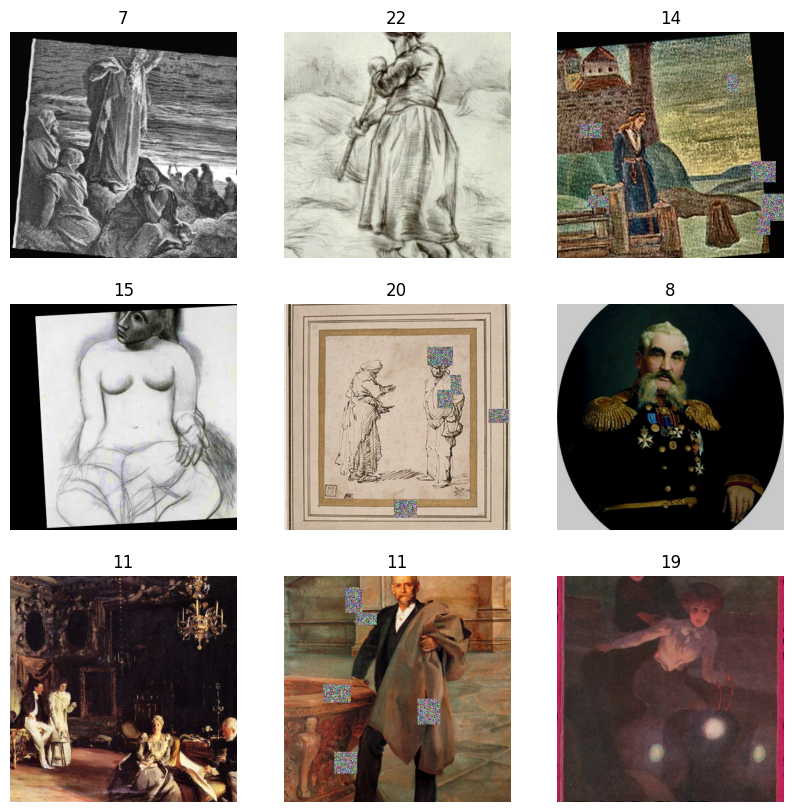

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def visualizar_dataset(dataset, class_names=None):
    plt.figure(figsize=(10, 10))
    
    # Extrai o primeiro batch (ex: 32 imagens)
    for images, labels in dataset.take(1):
        for i in range(9): # Visualizar as primeiras 9 imagens do batch
            ax = plt.subplot(3, 3, i + 1)
            
            # Converte para numpy e garante formato uint8 se necessário
            img = images[i].numpy()
            
            # Se os valores forem float entre 0 e 1, o imshow funciona diretamente.
            # Se forem entre 0-255, garantimos que são inteiros:
            if img.max() > 1.0:
                img = img.astype("uint8")
            
            plt.imshow(img)
            
            # Define o título com o nome da classe, se disponível
            if class_names:
                plt.title(class_names[labels[i]])
            else:
                # Usa np.argmax para lidar com One-Hot Encoding ou converter o tensor
                label_value = np.argmax(labels[i]) if labels[i].shape.rank > 0 else int(labels[i])
                plt.title(label_value)
                
            plt.axis("off")
    plt.show()

# Chamada da função
visualizar_dataset(train_ds)


## Weights

In [7]:
# Load class weights
with open('..\class_weights.json', 'r') as f:
    class_weights = json.load(f)
class_weights = {int(k): v for k, v in class_weights.items()}


## Model instantiation

In [8]:
clear_session() # Clear previous models from memory before instantiating new ones.

model_effnet   = TransferEfficientNetV2S(num_classes=N_CLASSES)
model_xception = TransferXception(num_classes=N_CLASSES)

transfer_models = [model_effnet, model_xception]

## Metrics and loss

In [9]:
def make_metrics(num_classes):
    """Return a fresh set of metric instances (metrics are stateful — each model needs its own)."""
    return [
        CategoricalAccuracy(name="accuracy"),
        AUC(multi_label=True, name="auc"),
        tfa.metrics.F1Score(num_classes=num_classes, average="macro", name="f1_score")
    ]


## Learning rate schedule

In [10]:
def make_cosine_warmup_scheduler(base_lr, total_epochs, warmup_epochs=5):
    """
    Cosine annealing with linear warmup.

    Warmup: LR ramps linearly from 0 to base_lr over the first warmup_epochs.
    This prevents the randomly initialised head from producing large gradients
    that destabilise the pretrained base at the start of training.

    Cosine decay: LR then follows a cosine curve from base_lr down to ~0.
    Finds better minima than step-decay or exponential decay in practice.
    """
    def scheduler(epoch, lr):
        if epoch < warmup_epochs:
            return base_lr * (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return base_lr * 0.5 * (1.0 + math.cos(math.pi * progress))
    return scheduler


## Phase 1 — Train heads with frozen base

Only the GAP + Dropout + Dense head is updated.  
The pretrained base is completely frozen.


In [ ]:
phase1_fit_data = {}

for model in transfer_models:
    model_name = model.name
    print(f"\n{'='*60}")
    print(f"Phase 1 training: {model_name}")
    print(f"{'='*60}")


    model.compile(
        optimizer=SGD(learning_rate=PHASE1_LR, decay=1e-4),
        loss=CategoricalCrossentropy(name="loss", label_smoothing=0.1),
        metrics=make_metrics(num_classes=N_CLASSES),
    )

    callbacks = [
        ModelCheckpoint(
            checkpoints_folder_path / f"ckpt_phase1_{model_name}.tf",
            monitor="val_loss", save_best_only=True, verbose=1,
        ),
        CSVLogger(metrics_folder_path / f"log_phase1_{model_name}.csv"),
        LearningRateScheduler(
            make_cosine_warmup_scheduler(PHASE1_LR, PHASE1_EPOCHS, warmup_epochs=3)
        ),
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ]

    history = model.fit(
        train_ds_mixed,
        validation_data=val_ds,
        epochs=PHASE1_EPOCHS,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1,
    )
    phase1_fit_data[model_name] = history

print("\nPhase 1 complete.")



Phase 1 training: transfer_effnetv2s
Epoch 1/15
582/582 [==============================] - ETA: 0s - loss: 3.1203 - accuracy: 0.0754 - auc: 0.5296 - f1_score: 0.0542
Epoch 1: val_loss improved from inf to 3.21534, saving model to Checkpoints\ckpt_phase1_transfer_effnetv2s.tf


INFO:tensorflow:Assets written to: Checkpoints\ckpt_phase1_transfer_effnetv2s.tf\assets


INFO:tensorflow:Assets written to: Checkpoints\ckpt_phase1_transfer_effnetv2s.tf\assets


582/582 [==============================] - 336s 384ms/step - loss: 3.1203 - accuracy: 0.0754 - auc: 0.5296 - f1_score: 0.0542 - val_loss: 3.2153 - val_accuracy: 0.0512 - val_auc: 0.5389 - val_f1_score: 0.0349 - lr: 0.0333
Epoch 2/15
582/582 [==============================] - ETA: 0s - loss: 3.0970 - accuracy: 0.0886 - auc: 0.5527 - f1_score: 0.0656
Epoch 2: val_loss improved from 3.21534 to 3.20107, saving model to Checkpoints\ckpt_phase1_transfer_effnetv2s.tf


INFO:tensorflow:Assets written to: Checkpoints\ckpt_phase1_transfer_effnetv2s.tf\assets


INFO:tensorflow:Assets written to: Checkpoints\ckpt_phase1_transfer_effnetv2s.tf\assets


582/582 [==============================] - 333s 410ms/step - loss: 3.0970 - accuracy: 0.0886 - auc: 0.5527 - f1_score: 0.0656 - val_loss: 3.2011 - val_accuracy: 0.0527 - val_auc: 0.5700 - val_f1_score: 0.0403 - lr: 0.0667
Epoch 3/15
582/582 [==============================] - ETA: 0s - loss: 3.0801 - accuracy: 0.0867 - auc: 0.5632 - f1_score: 0.0709

## Phase 2 — Fine-tune unfrozen base layers

Unfreeze the top portion of each pretrained base and retrain at a much lower LR.  
Early layers learn generic features (edges, textures) that transfer well — keep them frozen.  
Later layers learn task-specific patterns — retrain these on art data.


In [ ]:
phase2_fit_data = {}

for model in transfer_models:
    model_name = model.name
    print(f"\n{'='*60}")
    print(f"Phase 2 fine-tuning: {model_name}")
    print(f"{'='*60}")

    # Unfreeze top layers — defaults are set inside each model class
    model.unfreeze_base()

    # Recompile at ~100× lower LR to avoid overwriting pretrained representations
    model.compile(
        optimizer=SGD(learning_rate=PHASE2_LR, decay=1e-5),
        loss=CategoricalCrossentropy(name="loss", label_smoothing=0.1),
        metrics=make_metrics(num_classes=N_CLASSES),
    )

    callbacks = [
        ModelCheckpoint(
            checkpoints_folder_path / f"ckpt_phase2_{model_name}.tf",
            monitor="val_loss", save_best_only=True, verbose=1,
        ),
        CSVLogger(metrics_folder_path / f"log_phase2_{model_name}.csv"),
        LearningRateScheduler(
            make_cosine_warmup_scheduler(PHASE2_LR, PHASE2_EPOCHS, warmup_epochs=2)
        ),
        # More patience in Phase 2 — improvements are smaller and slower
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    ]

    history = model.fit(
        train_ds_mixed,
        validation_data=val_ds,
        epochs=PHASE2_EPOCHS,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1,
    )
    phase2_fit_data[model_name] = history

print("\nPhase 2 complete.")



Phase 2 fine-tuning: transfer_effnetv2s
transfer_effnetv2s: 100/513 base layers frozen, 413 unfrozen
Epoch 1/40
583/583 [==============================] - ETA: 0s - loss: 2.6721 - accuracy: 0.3430 - auc: 0.6930 - f1_score: 0.2910
Epoch 1: val_loss improved from inf to 2.46926, saving model to Checkpoints\ckpt_phase2_transfer_effnetv2s.tf


INFO:tensorflow:Assets written to: Checkpoints\ckpt_phase2_transfer_effnetv2s.tf\assets


INFO:tensorflow:Assets written to: Checkpoints\ckpt_phase2_transfer_effnetv2s.tf\assets


583/583 [==============================] - 412s 676ms/step - loss: 2.6721 - accuracy: 0.3430 - auc: 0.6930 - f1_score: 0.2910 - val_loss: 2.4693 - val_accuracy: 0.4709 - val_auc: 0.8936 - val_f1_score: 0.4414 - lr: 5.0000e-05
Epoch 2/40
 18/583 [..............................] - ETA: 4:23 - loss: 2.6824 - accuracy: 0.3194 - auc: 0.6821 - f1_score: 0.2553

KeyboardInterrupt: 